In [1]:
%load_ext autoreload

In [2]:
import os

In [3]:
# FILL THIS IN FOR YOUR OWN USE
save_dir = "/orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning"
wandb_entity = "JacobianODE"

In [4]:
data_loading_method = "from_file"
# data_loading_method = "in_memory"

## Custom Data Loader Demo

This notebook demonstrates how to use custom data arrays with the JacobianODE framework.

**Data Format**: Custom data must be in the format **Trials x Timepoints x Variables**
- Trials: Number of independent trajectories/trials
- Timepoints: Number of time steps in each trajectory
- Variables: Number of dimensions/variables observed at each time point

## Make Custom Data

In [ ]:
%autoreload 2
from JacobianODE.jacobians import TimeSeriesData

curr_dir = os.getcwd()
data_dir = os.path.join(curr_dir, 'example_data')
os.makedirs(data_dir, exist_ok=True)
obs_noise = 0.01
file_path = os.path.join(data_dir, f'lorenz_data_obs_noise_{obs_noise}.npz')
if os.path.exists(file_path):
    print(f"Loading data from {file_path}")
    custom_data = TimeSeriesData.load(file_path)
else:
    # Generate Lorenz data
    from omegaconf import OmegaConf
    from JacobianODE.jacobians import (
        load_config,
        initialize_config,
        make_trajectories,
        seed_everything,
    )

    # load the config
    overrides = [
        "data=dysts",
        "data.flow._target_=JacobianODE.dysts_sim.flows.Lorenz",
        f"data.postprocessing.obs_noise={obs_noise}",
        f"training.logger.save_dir={save_dir}",
    ]
    cfg = load_config(overrides=overrides)

    cfg = initialize_config(cfg)

    seed_everything(cfg.data.flow.random_state + cfg.training.run_number)
    eq, sol, dt = make_trajectories(cfg)

    custom_data = TimeSeriesData(
        values=sol['values'],
        dt=dt,
        metadata=OmegaConf.to_container(cfg.data, resolve=True),
    )
    custom_data.save(file_path)

print(f"Data shape: {custom_data.shape}  (trials={custom_data.n_trials}, time={custom_data.n_timepoints}, dims={custom_data.n_dims})")
print(f"dt: {custom_data.dt}")
print(f"Metadata: {custom_data.metadata}")

Loading data from /orcd/home/002/eisenaj/code/JacobianODE/_jupyter/example_data/lorenz_data_obs_noise_0.01.npz
Data shape: (32, 1200, 3)  (trials=32, time=1200, dims=3)
dt: 0.015020517097581317
Metadata: {'flow': {'random_state': 42, '_target_': 'JacobianODE.dysts_sim.flows.Lorenz', 'dt': None}, 'postprocessing': {'obs_noise': 0.01, 'filter_data': False, 'low_pass': 10, 'high_pass': None, 'normalize': False}, 'train_test_params': {'seq_length': 25, 'seq_spacing': 1, 'split_by': 'trajectory', 'train_percent': 0.7, 'test_percent': 0.1, 'dtype': 'torch.FloatTensor', 'verbose': True, 'delay_embedding_params': {'observed_indices': 'all', 'n_delays': 1, 'delay_spacing': 1}}, 'data_type': 'dysts', 'trajectory_params': {'n_periods': 12, 'method': 'Radau', 'resample': True, 'pts_per_period': 100, 'return_times': True, 'standardize': False, 'noise': 0.0, 'num_ics': 32, 'new_ic_mode': 'random', 'traj_offset_sd': 0.2, 'verbose': True}}


## Run JacobianODE with custom data

In [60]:
from JacobianODE.jacobians import (
    load_config,
    initialize_config,
    make_trajectories,
    postprocess_data,
    normalize_data,
)

# Common overrides for both loading methods
common_overrides = [
    "data=custom",
    "data.name=LorenzCustom",
    "data.postprocessing.obs_noise=0",
    "training.lightning.loop_closure_weight=0.001",
    f"training.logger.save_dir={save_dir}",
    f"wandb_entity={wandb_entity}",
]

if data_loading_method == "from_file":
    # Load from a TimeSeriesData .npz file (dt is read from the file automatically)
    cfg = load_config(
        overrides=common_overrides,
        custom_dataset_loader="JacobianODE.jacobians.custom_data.load_timeseries_data",
        custom_dataset_loader_kwargs={"file_path": file_path},
        data_dim=custom_data.n_dims,
    )
    cfg = initialize_config(cfg)
    eq, sol, dt = make_trajectories(cfg)
else:
    # In-memory: pass data directly to make_trajectories (no file I/O needed)
    cfg = load_config(overrides=common_overrides)
    cfg = initialize_config(cfg, data_dim=custom_data.n_dims)
    eq, sol, dt = make_trajectories(cfg, data=custom_data.values, dt=custom_data.dt)

In [61]:
values_raw = sol['values']
print(f"Loaded data shape: {values_raw.shape}")  # Should be (Trials, Timepoints, Variables)

# For custom data, we typically don't have alternative noise data
raw_values_noise = None

# ----------------------------------------
# POSTPROCESS DATA
# ----------------------------------------
# Postprocess data (adds noise, filtering, etc. based on config)
values = postprocess_data(cfg, values_raw, raw_values_noise, dt=dt)
if cfg.data.postprocessing.normalize:
    print(f"Normalizing data")
    values, mu, sigma = normalize_data(values)
else:
    print(f"Not normalizing data")
    mu = 0
    sigma = 1

print(f"Postprocessed data shape: {values.shape}")

Loaded data shape: (32, 1200, 3)
Not normalizing data
Postprocessed data shape: (32, 1200, 3)


At this point, the array `values` is an np.ndarray of shape (Trials, Timepoints, Variables) and is ready to be used for training.

The data is now ready for:
1. Creating dataloaders: `create_dataloaders(cfg, values)`
2. Training: `train_jacobians(cfg)`

In [62]:
%autoreload 2
from JacobianODE.jacobians import (
    create_dataloaders,
    setup_wandb,
    make_model,
    log_training_info,
    train_model,
)

# Create dataloaders
train_dataloader, val_dataloader, test_dataloader, trajs = create_dataloaders(cfg, values)

# Set up wandb
name, project, entity = setup_wandb(cfg, trajs, prompt_entity=False)

# Make model
lit_model = make_model(cfg, dt, eq=eq, project=project, mu=mu, sigma=sigma, verbose=True)

# Log training info
log_training_info(train_dataloader, trajs, lit_model)

# Train model (uncomment to actually train)
train_model(cfg, lit_model, train_dataloader, val_dataloader, name, project, entity=entity)

wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
/orcd/home/002/eisenaj/code/JacobianODE/.venv/lib64/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3 /orcd/home/002/eisenaj/code/JacobianODE/.venv/lib64 ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


RuntimeError: Lightning can't create new processes if CUDA is already initialized. Did you manually call `torch.cuda.*` functions, have moved the model to the device, or allocated memory on the GPU any other way? Please remove any such calls, or change the selected strategy. You will have to restart the Python kernel.

## Testing with Custom Data

In [5]:
run_id = 'kya4cr5p'

# Project name matches the notebook config (data.name=LorenzCustom)
# Format: entity/project for W&B API path (entity/project/run_id)
project = "LorenzCustom__JacobianODE"
project_path = f"{wandb_entity}/{project}" if wandb_entity else project

from JacobianODE.jacobians import load_run, load_checkpoint

run, cfg, eq, dt, values, train_dataloader, val_dataloader, test_dataloader, trajs, lit_model = load_run(
    project_path,
    run_id=run_id,
    save_dir=save_dir,
    no_noise=True,
    generate_data=True,
    verbose=True,
)

# Load best checkpoint into the model
load_checkpoint(run, cfg, lit_model, save_dir=save_dir, verbose=True)

lit_model.eval()


LitMLP(
  (model): MLP(
    (layers): ModuleList(
      (0): Linear(in_features=3, out_features=256, bias=True)
      (1): SiLU()
      (2): Linear(in_features=256, out_features=1024, bias=True)
      (3): SiLU()
      (4): Linear(in_features=1024, out_features=2048, bias=True)
      (5): SiLU()
      (6): Linear(in_features=2048, out_features=2048, bias=True)
      (7): SiLU()
      (8): Linear(in_features=2048, out_features=9, bias=True)
    )
  )
  (criterion): MSELoss()
)

Overall R2 score: 0.9204950928688049


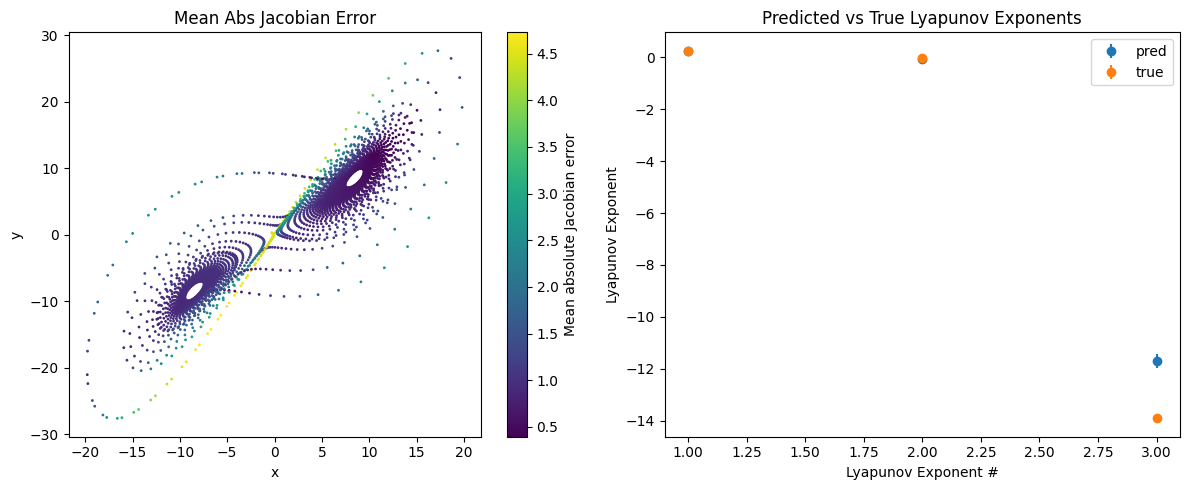

In [79]:
%autoreload 2
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from JacobianODE.jacobians.analysis import compute_lyaps
from JacobianODE.dysts_sim.flows import Lorenz

# True dynamics for Jacobian comparison (Lorenz generates this custom data)
eq_true = Lorenz() if eq is None else eq

# 2. Get test data and move to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lit_model = lit_model.to(device)
test_batch = trajs["test_trajs"].sequence.to(device)

# 3. Predicted Jacobians (model expects normalized input)
with torch.no_grad():
    jacs_pred = torch.stack([
        lit_model.compute_jacobians(test_batch[i].type(lit_model.dtype))
        for i in range(test_batch.shape[0])
    ]).cpu()

# 4. True Jacobians (denormalize for eq: x_orig = x_norm * sigma + mu)
def _to_numpy(x):
    return x.cpu().numpy() if isinstance(x, torch.Tensor) else np.asarray(x)

x_orig = (
    test_batch.cpu().numpy() * _to_numpy(lit_model.sigma) + _to_numpy(lit_model.mu)
).astype(np.float64)
n_trials, n_time, n_dim = x_orig.shape
t_indices = np.arange(n_time)*dt
jacs_true_np = eq_true.jac(x_orig, t_indices)
jacs_true = torch.from_numpy(jacs_true_np).float()

# 5. Compute error and plot
print(f"Overall R2 score: {r2_score(jacs_pred.flatten(), jacs_true.flatten())}")
jac_error = (jacs_pred - jacs_true).abs()
error_per_point = jac_error.mean(dim=(2, 3)).numpy()

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# First subplot: scatter of mean absolute Jacobian error
sc = axs[0].scatter(
    x_orig[:, :, 0].flatten(),
    x_orig[:, :, 1].flatten(),
    c=error_per_point.flatten(),
    s=1,
    cmap="viridis",
)
cb = fig.colorbar(sc, ax=axs[0], label="Mean absolute Jacobian error")
axs[0].set_title("Mean Abs Jacobian Error")
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")

# Second subplot: Lyapunov spectrum
lyaps_pred = compute_lyaps(torch.linalg.matrix_exp(jacs_pred*dt), dt=dt)
lyaps_true = compute_lyaps(torch.linalg.matrix_exp(jacs_true*dt), dt=dt)
# make the size of the points bigger
# add error bars on the estimated lyaps (standard error of the mean)
lyap_pred_mean = lyaps_pred.mean(dim=0)
lyap_pred_sem = lyaps_pred.std(dim=0) / np.sqrt(lyaps_pred.shape[0])
lyap_true_mean = lyaps_true.mean(dim=0)
lyap_true_sem = lyaps_true.std(dim=0) / np.sqrt(lyaps_true.shape[0])

x_vals = np.arange(1, lyap_pred_mean.shape[0] + 1)
# capsize=0 removes horizontal caps so error bars are purely vertical (along y)
axs[1].errorbar(x_vals, lyap_pred_mean, yerr=lyap_pred_sem, fmt='.', label='pred', markersize=12, capsize=0)
axs[1].errorbar(x_vals, lyap_true_mean, yerr=lyap_true_sem, fmt='.', label='true', markersize=12, capsize=0)
axs[1].set_xlabel("Lyapunov Exponent #")
axs[1].set_ylabel("Lyapunov Exponent")
axs[1].set_title("Predicted vs True Lyapunov Exponents")
axs[1].legend()

plt.tight_layout()
plt.show()